In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from treasury_ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nVLBbuIwEP2VyHtOnIRAwQIqWoSWinYpBFbiZpIBLBI79TgE%2Fn4dAqvuoT2s5INlv5n3Zt7rP57zzDmBRqHkgASeTxyQiUqF3A%2FIKp64XeKg4TLlmZIwIBdA8jjsI8%2Bzgo1Kc5AL%2BCgBjWMbSWT1x4CUWjLFUSCTPAdkJmHL0euMhZ7POCJoY%2BnIrSRFYbkOxhSM0qqqvKrlKb2noe%2F71O9Ri6ohP8gniuJ7jkIroxKV3UvOdqYvKALqRzWFRViG%2Ba3wSchmBd%2BxbBsQsp9xPHfnv5YxcUb36Z6VxDIHvQR9EgmsFrNGAFoFizh8iMKuB6WbgDSaZ27goVTVLuNHSFRelMY29uyN7iClmdoLu67peECKo0hVEmG17U3eX4%2Bnp%2BCwPcjO5n0yW798BIXaF1H4O44WW3GGl25CnPXd3LA2d4pYwlTWlhr75Icd1w%2Ftif2QtQPWbnmdXmtDnLG1VEhurpV33VapxB3oSiB46mi4Cznwq0xeFPTvBBTOx0igKbbt%2FWZ1WXdLXzxQREVr70gTH3aVoof%2FsZQ%2B%2FdzgFsY36890PFeZSC7OROmcm6%2FtC7zg%2BiJSd3eFMsi5yEZpqgHR2phlqnrWwI3NvNElEDpsWP9N%2

In [5]:
pnl_df = snowflake_client.fetch(

'''
select HOUR_TIMESTAMP, ccy, sum(FX_PNL) as total_fx_pnl
from RPT_TREASURY.TREASURY_FX_PNL_HOURLY
where ccy in ('MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
and HOUR_TIMESTAMP::date >= '2024-01-01'
group by all

'''
)

exposure_df = snowflake_client.fetch(
'''
with position as
(SELECT ccy
    , case
          when minute(created_at) > 30
              then time_slice(created_at, 1, 'hour', 'end')
          else time_slice(created_at, 1, 'hour', 'start') end
             as hour_timestamp
    , sum(amount) as hour_position
FROM ARM.OPEN_POSITION_AUDIT
WHERE TYPE IN ('CUSTOMER',
              'BORDERLESS',
              'HEDGE')
 AND hour_timestamp >= '2024-01-01'
and ccy in ('THB','MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
group by all),

rates as (
    select MINUTE_TIMESTAMP, target_ccy, SOURCE_CCY, value
    from RATE_HISTORICAL.ANALYTICS_RATES
    where TARGET_CCY in ('GBP', 'USD')
    and minute_timestamp >= '2024-01-01')

select position.*,
       rates_usd.value as rate_to_usd,
       rates_gbp.value as rate_to_gbp
from position
left join rates as rates_usd
    on rates_usd.MINUTE_TIMESTAMP = hour_timestamp
    and rates_usd.TARGET_CCY = 'USD'
    and rates_usd.SOURCE_CCY = position.ccy
left join rates as rates_gbp
    on rates_gbp.MINUTE_TIMESTAMP = hour_timestamp
    and rates_gbp.TARGET_CCY = 'GBP'
    and rates_gbp.SOURCE_CCY = position.ccy
'''

)

In [6]:
pnl_df

,hour_timestamp,ccy,total_fx_pnl
0,2025-12-25 09:00:00,IDR,-58.177039
1,2025-12-25 01:00:00,INR,-7263.289310
2,2025-12-24 15:00:00,KRW,4143.055516
3,2025-12-24 14:00:00,KRW,-3157.923711
4,2025-12-23 07:00:00,IDR,-5539.964134
...,...,...,...
128200,2026-01-24 19:00:00,IDR,14.412179
128201,2026-01-24 19:00:00,INR,-260.575254
128202,2026-01-22 04:00:00,PHP,7626.503380
128203,2026-01-22 02:00:00,IDR,-6140.927422


In [7]:
#pnl_df = pd.read_csv('/Users/joshua.choy/Downloads/total_fx_pnl_2024_onwards.csv')
# exposure_df = pd.read_csv('/Users/joshua.choy/Downloads/exposure_2024_onwards.csv')

pnl_df['hour_timestamp'] = pd.to_datetime(pnl_df['hour_timestamp'])
exposure_df['hour_timestamp'] = pd.to_datetime(exposure_df['hour_timestamp'])

In [8]:
print(exposure_df.columns)
print(pnl_df.columns)

Index(['ccy', 'hour_timestamp', 'hour_position', 'rate_to_usd', 'rate_to_gbp'], dtype='object')
Index(['hour_timestamp', 'ccy', 'total_fx_pnl'], dtype='object')


In [62]:
sorted_pnl = pnl_df.sort_values(by=['hour_timestamp'])
sorted_exposure = exposure_df.sort_values(by=['hour_timestamp'])
df = pd.merge(exposure_df, pnl_df[['hour_timestamp', 'ccy', 'total_fx_pnl']], on=["hour_timestamp", 'ccy'], how='left')
df['usd_rate'] = 1/df['rate_to_usd']
df['gbp_rate'] = 1/df['rate_to_gbp']
df['position_in_USD'] = df['hour_position'] / df['usd_rate']
df['position_in_GBP'] = df['hour_position'] / df['gbp_rate']
df.head()

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
0,THB,2024-02-15 20:00:00,1.309710e+07,0.027728,0.022011,24.778688,36.064498,45.432242,3.631577e+05,2.882777e+05
1,KRW,2024-02-09 12:00:00,6.208406e+09,0.000751,0.000596,-1219.079264,1331.557923,1678.697331,4.662513e+06,3.698347e+06
2,INR,2024-02-09 12:00:00,3.318016e+09,0.012044,0.009553,11887.662008,83.025447,104.674775,3.996384e+07,3.169833e+07
3,KRW,2024-02-15 19:00:00,9.479931e+08,0.000751,0.000596,-96.547312,1331.557923,1676.727029,7.119428e+05,5.653831e+05
4,VND,2024-02-15 19:00:00,-3.133371e+10,0.000041,0.000032,-56.772561,24449.877751,30769.230769,-1.281549e+06,-1.018346e+06


In [63]:
def filter_df(df, day_of_week:int, hour_of_day:int):
    '''
    :param dataframe: dataframe of exposure data
    
    :param day_of_week: int to represent day of week, Mon = 0 and Sun = 6
    :param hour_of_day: hour of day in UTC
    '''
    mask = (
        (df['hour_timestamp'].dt.dayofweek == day_of_week) & 
        (df['hour_timestamp'].dt.hour == hour_of_day) 
        # (df['ccy'] == ccy )
    )

    return df.loc[mask]

In [67]:
monday_df = filter_df(df, 0, 0)
monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()
monday_df.sort_values('abs_position_USD', ascending=False).head()

/var/folders/r6/lyd4620542j8pdy7dl_ccjtw0000gp/T/ipykernel_60409/4035449270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()


,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,abs_position_USD
118774,INR,2025-09-01,-4.109559e+09,0.011341,0.008399,41196.473389,88.174091,119.066046,-4.660733e+07,-3.451495e+07,4.660733e+07
7808,IDR,2025-03-31,7.641236e+11,0.000060,0.000047,-76352.894004,16556.291391,21413.276231,4.615306e+07,3.568457e+07,4.615306e+07
110682,PHP,2025-12-08,2.508880e+09,0.016958,0.012726,-16444.894062,58.969566,78.579904,4.254534e+07,3.192776e+07,4.254534e+07
82478,INR,2026-01-26,-3.854437e+09,0.010908,0.007983,8888.483584,91.674994,125.259914,-4.204459e+07,-3.077152e+07,4.204459e+07
87366,THB,2025-10-20,-1.317174e+09,0.030465,0.022692,5168.697382,32.824984,44.069171,-4.012719e+07,-2.988879e+07,4.012719e+07


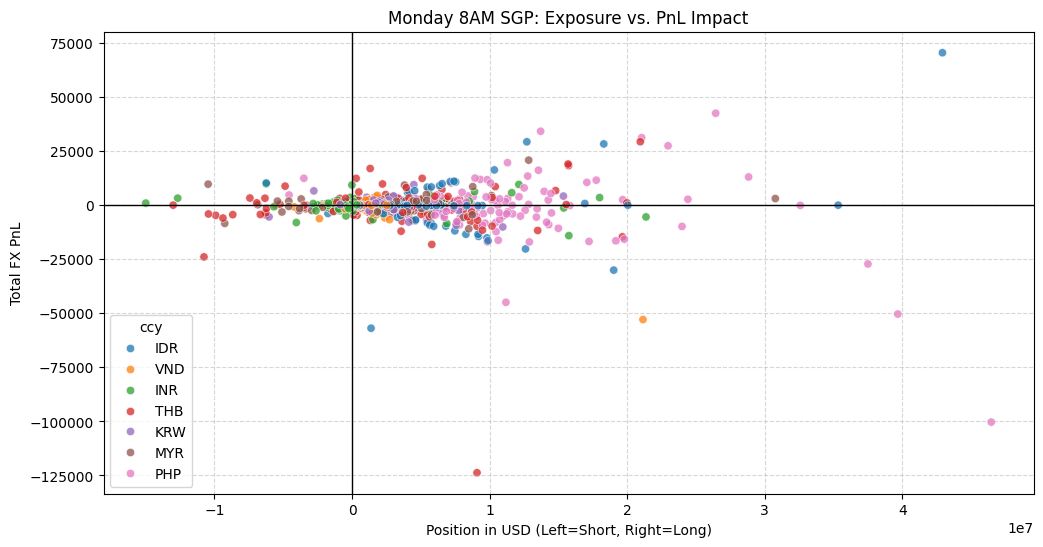

In [85]:
plt.figure(figsize=(12, 6))

# Plotting only the Monday 8am Slice
sns.scatterplot(
    data=monday_df,
    x='position_in_USD', # Use signed position to see Direction (Long/Short)
    y='total_fx_pnl',
    hue='ccy',           # Color by currency     # Dot size = Size of the PnL impact
    sizes=(50, 400),
    alpha=0.75
)

plt.title('Monday 8AM SGP: Exposure vs. PnL Impact')
plt.xlabel('Position in USD (Left=Short, Right=Long)')
plt.ylabel('Total FX PnL')
plt.axhline(0, color='black', linewidth=1) # Zero PnL line
plt.axvline(0, color='black', linewidth=1) # Zero Position line
plt.grid(True, linestyle='--', alpha=0.5)


plt.show()

In [ ]:
import plotly.express as px
import pandas as pd


df['hour_timestamp'] = pd.to_datetime(df['hour_timestamp'])
monday_df['date_str'] = monday_df['hour_timestamp'].dt.strftime('%Y-%m-%d')

# --- CREATING THE INTERACTIVE PLOT ---
fig = px.scatter(
    monday_df,
    x='position_in_USD',
    y='total_fx_pnl',
    color='ccy',                 # Different color per currency
    size=monday_df['total_fx_pnl'].abs(), # Bubble size based on PnL magnitude
    hover_name='ccy',            # Title of the tooltip
    hover_data={                 # Customizing what shows up when you hover
        'date_str': True,
        'position_in_USD': ':,.0f', # Format with commas
        'total_fx_pnl': ':,.2f',    # Format with 2 decimals
        'usd_rate': ':.6f',      # Show the rate used
        'ccy': False,               # Already in title
        'hour_timestamp': False     # Replaced by date_str
    },
    title='Monday 8AM SGP Exposure vs. PnL Impact',
    template='plotly_white',      # Clean background
    height=600                    # Taller chart
)


fig.add_hline(y=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
fig.add_vline(x=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
fig.show()

In [81]:
monday_df.loc[monday_df['ccy'] == 'PHP'].sort_values('total_fx_pnl', ascending=True)

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,date_str
117014,PHP,2024-12-23 08:00:00,2.717961e+09,0.017093,0.013611,-100313.755327,58.503139,73.467828,4.645838e+07,3.699525e+07,2024-12-23
39685,PHP,2025-12-29 08:00:00,2.333071e+09,0.017001,0.012607,-50319.237063,58.820069,79.318495,3.966454e+07,2.941396e+07,2025-12-29
47623,PHP,2025-05-12 08:00:00,6.203490e+08,0.018028,0.013690,-44883.983511,55.470501,73.046553,1.118340e+07,8.492516e+06,2025-05-12
52445,PHP,2024-04-08 08:00:00,2.117866e+09,0.017704,0.014021,-27148.699383,56.485048,71.320572,3.749427e+07,2.969502e+07,2024-04-08
119277,PHP,2026-01-19 08:00:00,7.660242e+08,0.016821,0.012563,-16968.970176,59.449851,79.600723,1.288522e+07,9.623333e+06,2026-01-19
...,...,...,...,...,...,...,...,...,...,...,...
120738,PHP,2025-01-20 08:00:00,6.611442e+08,0.017091,0.013992,19708.508551,58.512039,71.469411,1.129928e+07,9.250730e+06,2025-01-20
1637,PHP,2024-10-07 08:00:00,1.304467e+09,0.017607,0.013427,27517.260138,56.796883,74.474582,2.296723e+07,1.751560e+07,2024-10-07
75647,PHP,2025-07-07 08:00:00,1.192638e+09,0.017651,0.012970,31289.377219,56.653051,77.099219,2.105160e+07,1.546887e+07,2025-07-07
100699,PHP,2024-08-05 08:00:00,7.932761e+08,0.017278,0.013504,34260.439284,57.878744,74.049939,1.370583e+07,1.071272e+07,2024-08-05


In [18]:
np.percentile(abs(df.loc[df['ccy'] == 'PHP']['hour_position']), 80)

858411589.5840001

In [15]:
ccys = ['INR', 'VND', 'PHP', 'IDR', 'MYR', 'THB', 'KRW']    

In [16]:
print(filter_df(df, 0, 'INR', 0)['hour_position'].mean())
print(filter_df(df, 0, 'INR', 0)['total_fx_pnl'].mean())

print(filter_df(df, 0, 'THB', 0)['hour_position'].mean())
print(filter_df(df, 0, 'THB', 0)['total_fx_pnl'].mean())

print(filter_df(df, 0, 'PHP', 0)['hour_position'].mean())
print(filter_df(df, 0, 'PHP', 0)['total_fx_pnl'].mean())

-319753754.54454553
-552.6273979705497
-127396020.512
-435.40820037049997
49180514.95754546
967.7389469885928
